In [3]:
import zipfile
import os

# ZIP file names
en_zip = "English_adjectives.zip"
de_zip = "German_translations.zip"   # change this to your actual filename

# Output folders
en_folder = "/content/English_adjectives"
de_folder = "/content/German_translations"

# Create folders
os.makedirs(en_folder, exist_ok=True)
os.makedirs(de_folder, exist_ok=True)

# Extract English
with zipfile.ZipFile(en_zip, "r") as zip_ref:
    zip_ref.extractall(en_folder)

# Extract German
with zipfile.ZipFile(de_zip, "r") as zip_ref:
    zip_ref.extractall(de_folder)

print("English files extracted to:", en_folder)
print("German files extracted to:", de_folder)

English files extracted to: /content/English_adjectives
German files extracted to: /content/German_translations


In [4]:
import pandas as pd
import glob
import os

def load_texts_from_folder(folder_path):
    """
    Read all .xlsx files in a folder and return one row per unique text.

    A text is identified by the 'file' column.
    Each text gets one Domain and Gender.
    """

    records = {}
    conflicts = []

    # Find all Excel files, including files in subfolders
    xlsx_files = glob.glob(
        os.path.join(folder_path, "**", "*.xlsx"),
        recursive=True
    )

    print(f"Found {len(xlsx_files)} Excel files in {folder_path}")

    if not xlsx_files:
        raise ValueError(f"No .xlsx files found in {folder_path}")

    for xlsx_path in xlsx_files:

        df = pd.read_excel(
            xlsx_path,
            usecols=["file", "Domain", "Gender"]
        )

        df = df.dropna(subset=["file"])

        for file_name, domain, gender in df[
            ["file", "Domain", "Gender"]
        ].itertuples(index=False):

            if file_name in records:

                if records[file_name] != (domain, gender):
                    conflicts.append(
                        (
                            file_name,
                            records[file_name],
                            (domain, gender),
                            xlsx_path
                        )
                    )

            else:
                records[file_name] = (domain, gender)

    if conflicts:
        print(
            f"\nWARNING: {len(conflicts)} texts had "
            "inconsistent Domain/Gender information."
        )

        print("First 5 conflicts:")
        for c in conflicts[:5]:
            print(c)

    out = pd.DataFrame(
        [
            (file_name, domain, gender)
            for file_name, (domain, gender) in records.items()
        ],
        columns=["file", "Domain", "Gender"]
    )

    return out

In [5]:
en_texts = load_texts_from_folder(en_folder)
de_texts = load_texts_from_folder(de_folder)

print("\nEnglish unique texts:", len(en_texts))
print("German unique texts:", len(de_texts))

Found 17 Excel files in /content/English_adjectives
Found 7 Excel files in /content/German_translations

English unique texts: 189
German unique texts: 156


In [6]:
def domain_gender_frequency_table(texts_df):

    table = pd.crosstab(
        texts_df["Domain"],
        texts_df["Gender"]
    )

    table["Total"] = table.sum(axis=1)

    # Add total row
    table.loc["Total"] = table.sum(axis=0)

    return table


def domain_gender_percentage_table(texts_df):

    # Count gender within each domain
    counts = pd.crosstab(
        texts_df["Domain"],
        texts_df["Gender"]
    )

    # Convert each domain to percentages
    percentages = counts.div(
        counts.sum(axis=1),
        axis=0
    ) * 100

    return percentages.round(2)

In [7]:
# English
en_frequency = domain_gender_frequency_table(en_texts)
en_percentage = domain_gender_percentage_table(en_texts)

# German
de_frequency = domain_gender_frequency_table(de_texts)
de_percentage = domain_gender_percentage_table(de_texts)

In [8]:
print("========== ENGLISH: RAW FREQUENCIES ==========")
display(en_frequency)

print("\n========== ENGLISH: PERCENTAGES ==========")
display(en_percentage)

print("\n========== GERMAN: RAW FREQUENCIES ==========")
display(de_frequency)

print("\n========== GERMAN: PERCENTAGES ==========")
display(de_percentage)

========== ENGLISH: RAW FREQUENCIES ==========


Gender,F,M,Total
Domain,,,
Art,6,10,16
Bus,6,10,16
Edu,9,6,15
Ent,7,8,15
His,7,7,14
Med,7,10,17
Phi,2,13,15
Pol,11,6,17
Psy,12,5,17



========== ENGLISH: PERCENTAGES ==========


Gender,F,M
Domain,,
Art,37.50,62.50
Bus,37.50,62.50
Edu,60.00,40.00
Ent,46.67,53.33
His,50.00,50.00
Med,41.18,58.82
Phi,13.33,86.67
Pol,64.71,35.29
Psy,70.59,29.41



========== GERMAN: RAW FREQUENCIES ==========


Gender,F,M,Total
Domain,,,
Art,4,10,14
Bus,5,9,14
Edu,9,6,15
Ent,5,4,9
His,6,5,11
Med,4,7,11
Phi,2,13,15
Pol,9,6,15
Psy,10,5,15



========== GERMAN: PERCENTAGES ==========


Gender,F,M
Domain,,
Art,28.57,71.43
Bus,35.71,64.29
Edu,60.00,40.00
Ent,55.56,44.44
His,54.55,45.45
Med,36.36,63.64
Phi,13.33,86.67
Pol,60.00,40.00
Psy,66.67,33.33


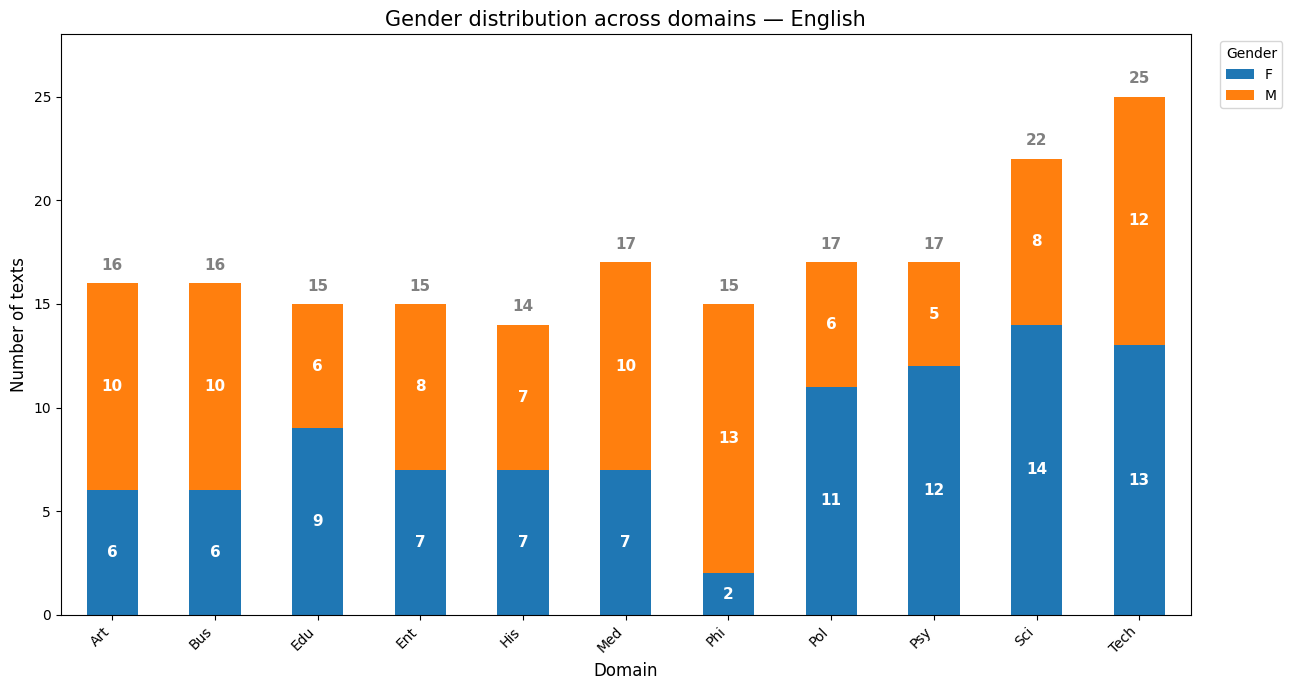

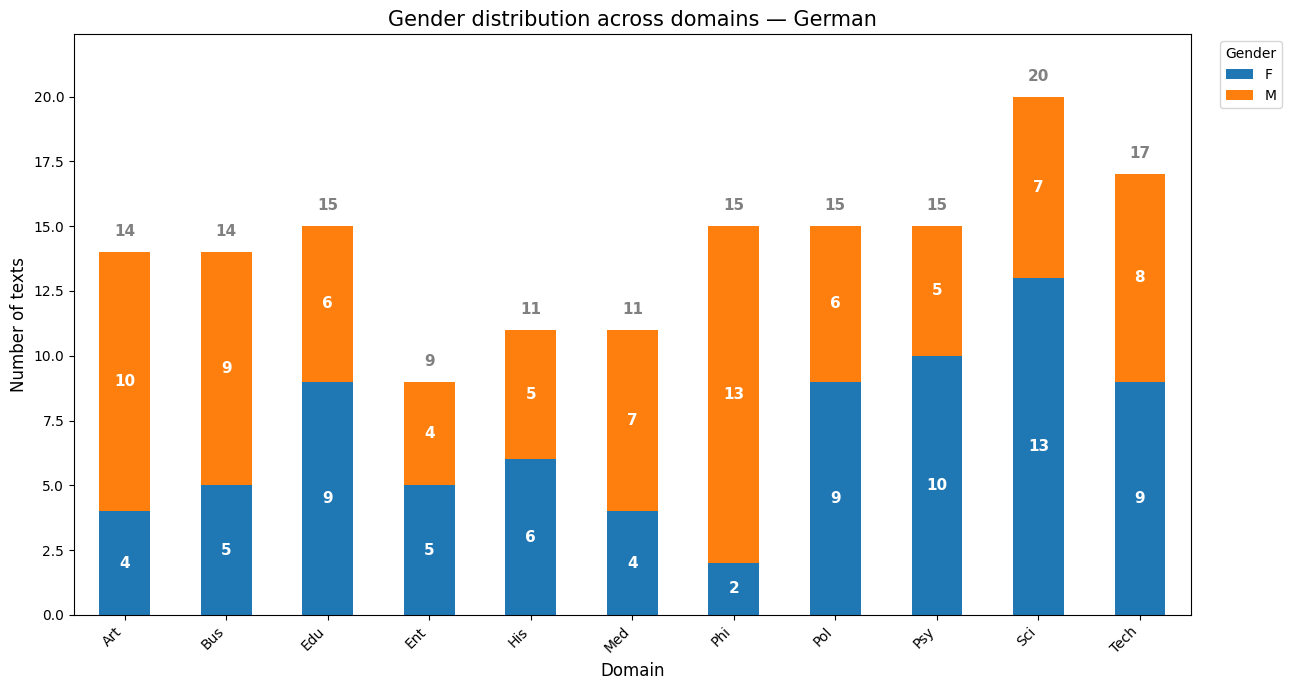

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.pyplot as plt
import pandas as pd

def plot_gender_stacked(df, title):

    # Count unique texts per Domain × Gender
    counts = pd.crosstab(
        df["Domain"],
        df["Gender"]
    )

    # Create figure
    fig, ax = plt.subplots(figsize=(13, 7))

    # Stacked bar chart
    counts.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    # Add individual counts inside each segment
    for bar_index, domain in enumerate(counts.index):

        cumulative = 0

        for gender in counts.columns:

            value = counts.loc[domain, gender]

            if value > 0:

                # Put count in middle of segment
                ax.text(
                    bar_index,
                    cumulative + value / 2,
                    str(value),
                    ha="center",
                    va="center",
                    color="white",
                    fontweight="bold",
                    fontsize=11
                )

                cumulative += value

        # Total above the bar
        total = counts.loc[domain].sum()

        ax.text(
            bar_index,
            total + 0.5,
            f"{total}",
            ha="center",
            va="bottom",
            fontweight="bold",
            color="gray",
            fontsize=11
        )

    # Labels
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Domain", fontsize=12)
    ax.set_ylabel("Number of texts", fontsize=12)

    # Rotate domain names
    plt.xticks(
        rotation=45,
        ha="right"
    )

    # Legend
    ax.legend(
        title="Gender",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    # Give some space above totals
    ax.set_ylim(
        0,
        counts.sum(axis=1).max() * 1.12
    )

    plt.tight_layout()
    plt.show()

# English
plot_gender_stacked(
    en_texts,
    "Gender distribution across domains — English"
)

# German
plot_gender_stacked(
    de_texts,
    "Gender distribution across domains — German"
)